# Questão 1

Erro: Arquivo não encontrado.
--- Informações Extraídas ---
Quantização: 16 bits
Total de amostras no arquivo: 21958
Taxa de Amostragem: 8012 Hz, Período de Amostragem: 0.00012481278082875687 s


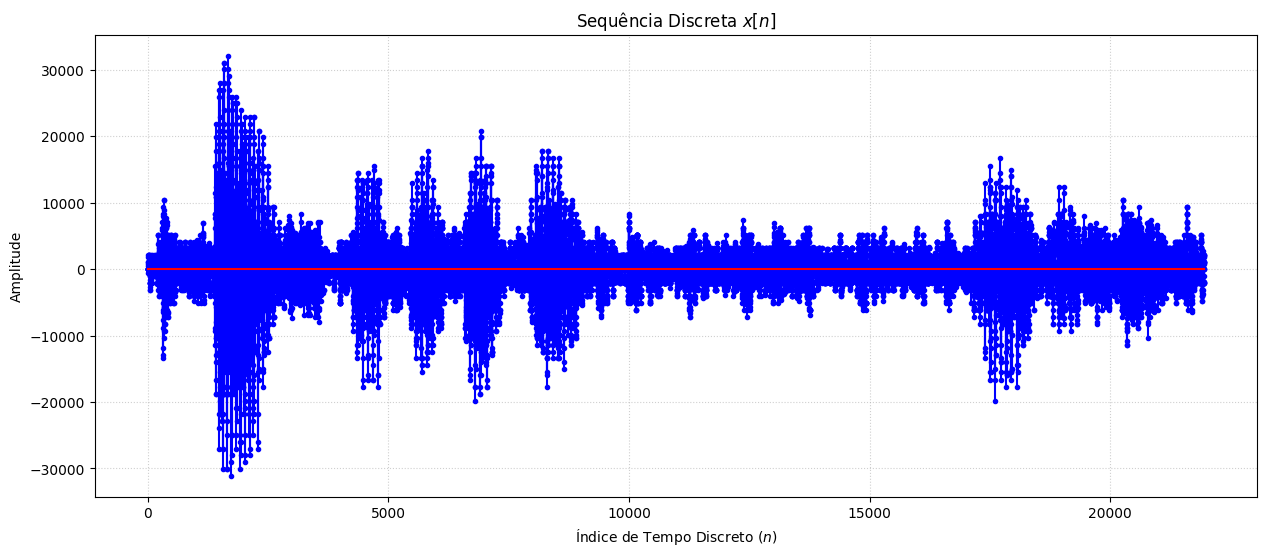

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

NOME_ARQUIVO = '../data/forcewithyou.wav'

try:
    fs, data = wavfile.read(NOME_ARQUIVO)
    if len(data.shape) > 1: data = data[:, 0] # Mono

    x_n = {
        'x': data,
        'N': data.shape[0],
        'fs': fs,
        'ts': 1/fs,
        'Resolution': data.dtype.itemsize * 8
    }
    print("Erro: Arquivo não encontrado.")
    
    print(f"--- Informações Extraídas ---")
    print(f"Quantização: {x_n['Resolution']} bits")
    print(f"Total de amostras no arquivo: {x_n['N']}")
    print(f"Taxa de Amostragem: {x_n['fs']} Hz, Período de Amostragem: {x_n['ts']} s")

except FileNotFoundError:
    print(f"Arquivo '{NOME_ARQUIVO}' não encontrado.")
    
def plot_x_n(sinal_dict, i, f, title):
    plt.figure(figsize=(15, 6))
    n = np.arange(i, f)
    plt.stem(n, sinal_dict['x'][i:f], linefmt='b-', markerfmt='.', basefmt='r-')
    plt.title(title)
    plt.xlabel("Índice de Tempo Discreto ($n$)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle=':', alpha=0.6)
    

plot_x_n(x_n, 0, x_n['N'], "Sequência Discreta $x[n]$")
plt.show()

# Questão 2

## (a)

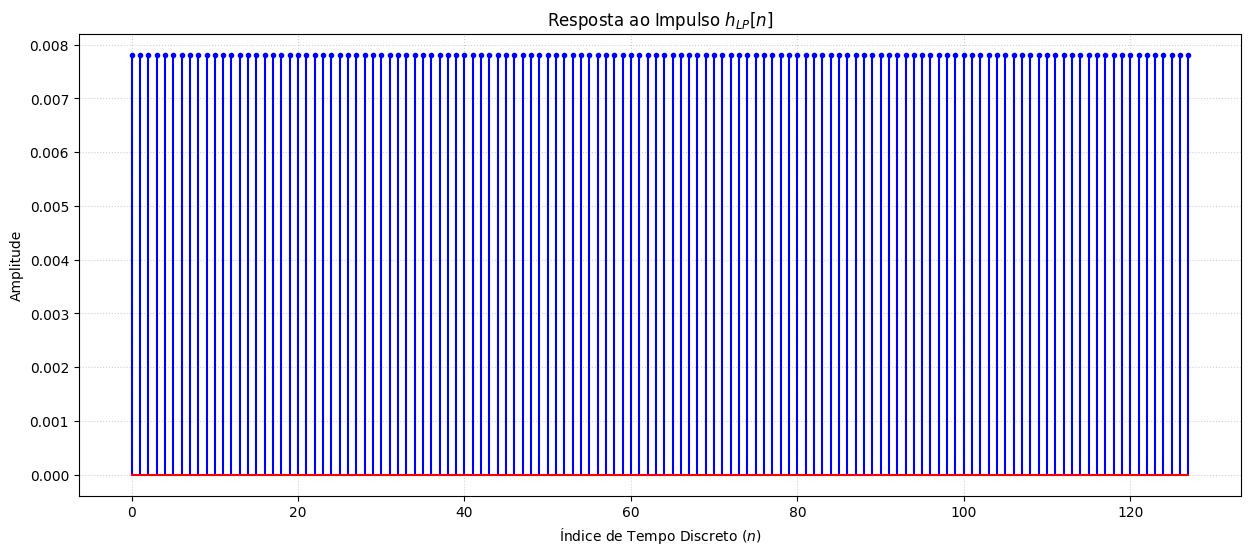

In [2]:
M = 128
h_lp_n = {
    'x': np.ones(M) * (1/M),
    'N': M,
    'fs': x_n['fs'],
    'ts': x_n['ts']
}
plot_x_n(h_lp_n, 0, M, r"Resposta ao Impulso $h_{LP}[n]$")
plt.show()


## (b)

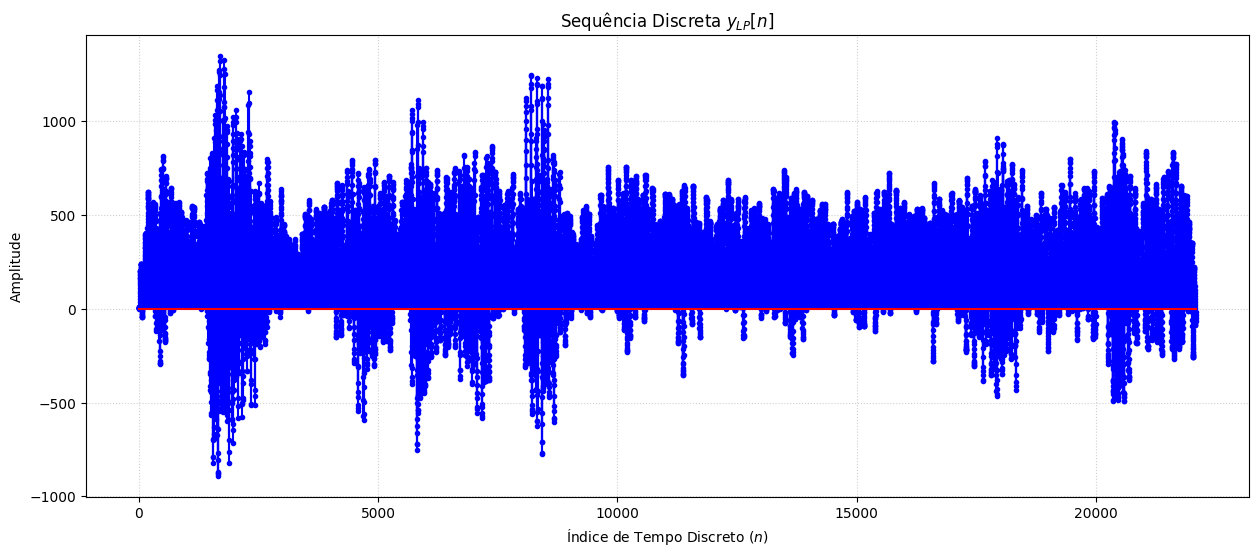

In [3]:
def conv_linear(x_dict, h_dict):
    Nx, Nh = x_dict['N'], h_dict['N']
    Ny = Nx + Nh - 1
    y = np.zeros(Ny)
    for n in range(Ny):
        for l in range(Nx):
            if 0 <= n-l < Nh:
                y[n] += x_dict['x'][l] * h_dict['x'][n-l]
    return {'x': y, 'N': Ny, 'fs': x_dict['fs']}

y_lp_n = conv_linear(x_n, h_lp_n)

plot_x_n(y_lp_n, 0, y_lp_n['N'], "Sequência Discreta $y_{LP}[n]$")
plt.show()

## (c)

In [4]:
def salvar_wav(sinal_dict, nome):
    sinal = sinal_dict['x'] / np.max(np.abs(sinal_dict['x']))
    sinal_int16 = (sinal * 32767).astype(np.int16)
    wavfile.write(nome, sinal_dict['fs'], sinal_int16)
    print(f"Sucesso! Arquivo '{nome}' salvo com {x_n['N']} amostras.")

salvar_wav(y_lp_n, "../data/forcewithyou_lp.wav")

Sucesso! Arquivo '../data/forcewithyou_lp.wav' salvo com 21958 amostras.


## (d)

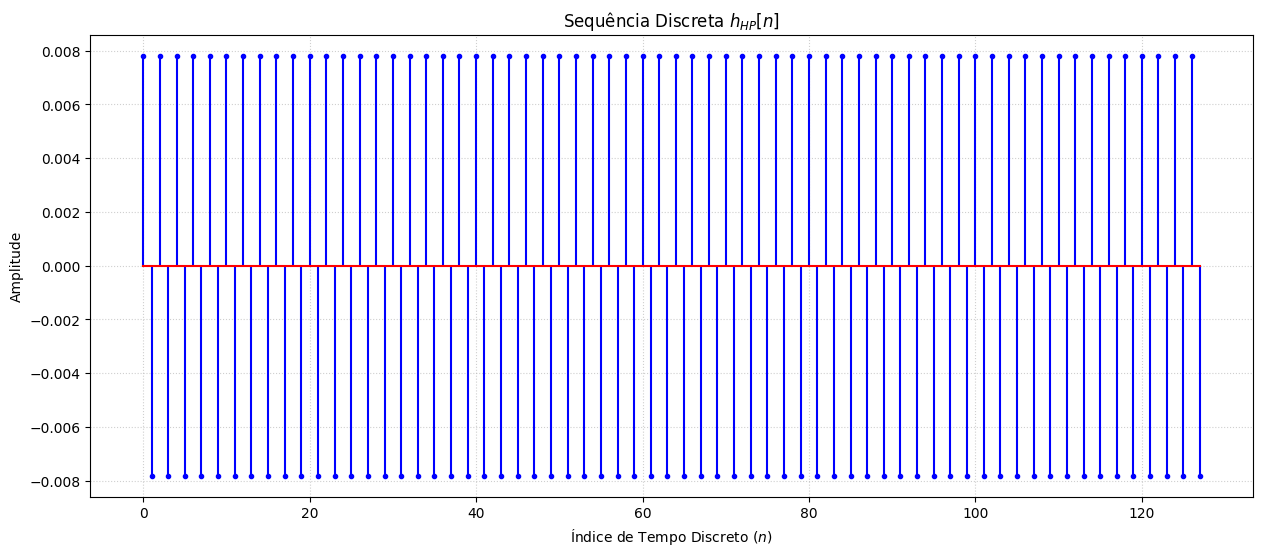

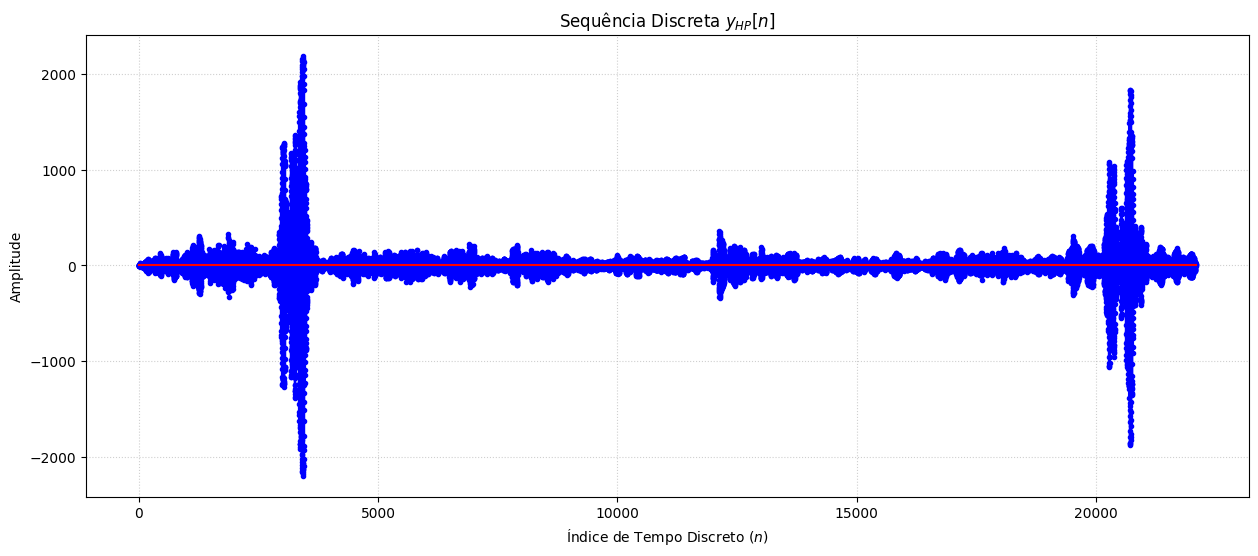

Sucesso! Arquivo '../data/forcewithyou_hp.wav' salvo com 21958 amostras.


In [5]:
M = 128
h_hp_x = np.array([((-1)**n) * h_lp_n['x'][n] for n in range(M)])
h_hp_n = {'x': h_hp_x, 'N': M, 'fs': x_n['fs']}

plot_x_n(h_hp_n, 0, h_hp_n['N'], "Sequência Discreta $h_{HP}[n]$")
plt.show()

y_hp_n = conv_linear(x_n, h_hp_n)
plot_x_n(y_hp_n, 0, y_hp_n['N'], "Sequência Discreta $y_{HP}[n]$")
plt.show()

salvar_wav(y_hp_n, "../data/forcewithyou_hp.wav")

# Questão 3

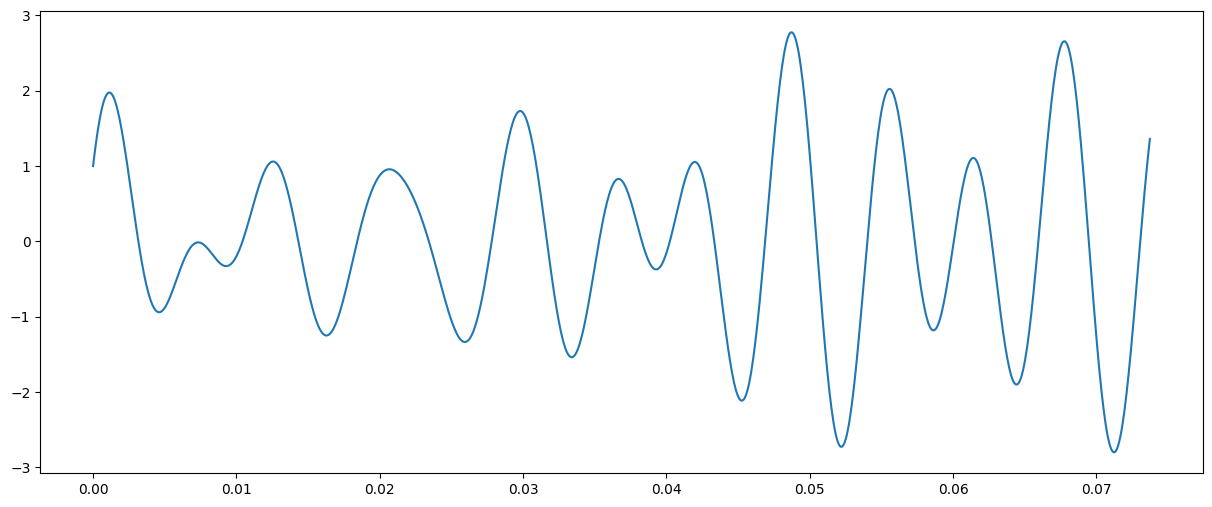

In [6]:
def x_t(t):
    return np.sin(300 * np.pi * t) + np.cos(325 * np.pi * t) + np.sin(217 * np.pi * t)

w_min = 217 * np.pi
f_min = (w_min)/(2* np.pi)
T_min =  1/(f_min)

t = np.linspace(0, 8 * T_min, 1000)

plt.figure(figsize=(15, 6))
plt.plot(t, x_t(t))
plt.show()

w_max = 325 * np.pi
f_max = w_max / (2 * np.pi)
T_max = 1/(f_max)



